# Experiment 1 — headline benchmark (LGD)

5-fold CV on the LGD datasets (loss-given-default regression on [0, 1]; tuned/HPO models). For every matrix metric — **R²**, **Pearson correlation** — the **same three views**: matrix, per-method bar (fold-level std), and an across-dataset box. The **rank by R²** (kept right after R²) gets the same three views. Then the **effect of HPO**, a **time analysis** (train + predict + HPO), a **prediction-calibration analysis**, and a summary. Foundation-model names are **red**. Figures → `figures/experiment1/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, metric_bars, metric_boxplots,
    rank_heatmap, method_ranking_bars, rank_boxplots,
    hpo_improvement_bars, compute_time_bars, compute_time_boxplot,
    runtime_performance_scatter, foundation_vs_baseline_size_trend,
    foundation_vs_baseline_scatter, calibration_bias_table,
    selected_method_calibration_summary, calibration_decile_curve,
    per_dataset_calibration_grid, per_dataset_prediction_density,
    pd_summary_text, lgd_summary_text, calibration_summary_text,
    rank_summary_text, hpo_effect_text, head_to_head_text,
)
from src.utils.report import notebook_report, capture, section
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1/lgd')


In [2]:
df      = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode='HPO')
df_both = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode=None)


[CONFIG_NOTEBOOKS.yaml] excluded from this analysis: tabfm
[CONFIG_NOTEBOOKS.yaml] excluded from this analysis: tabfm


## 1. R² — explained variance

Matrix · per-method bar (fold-level std) · across-dataset box.

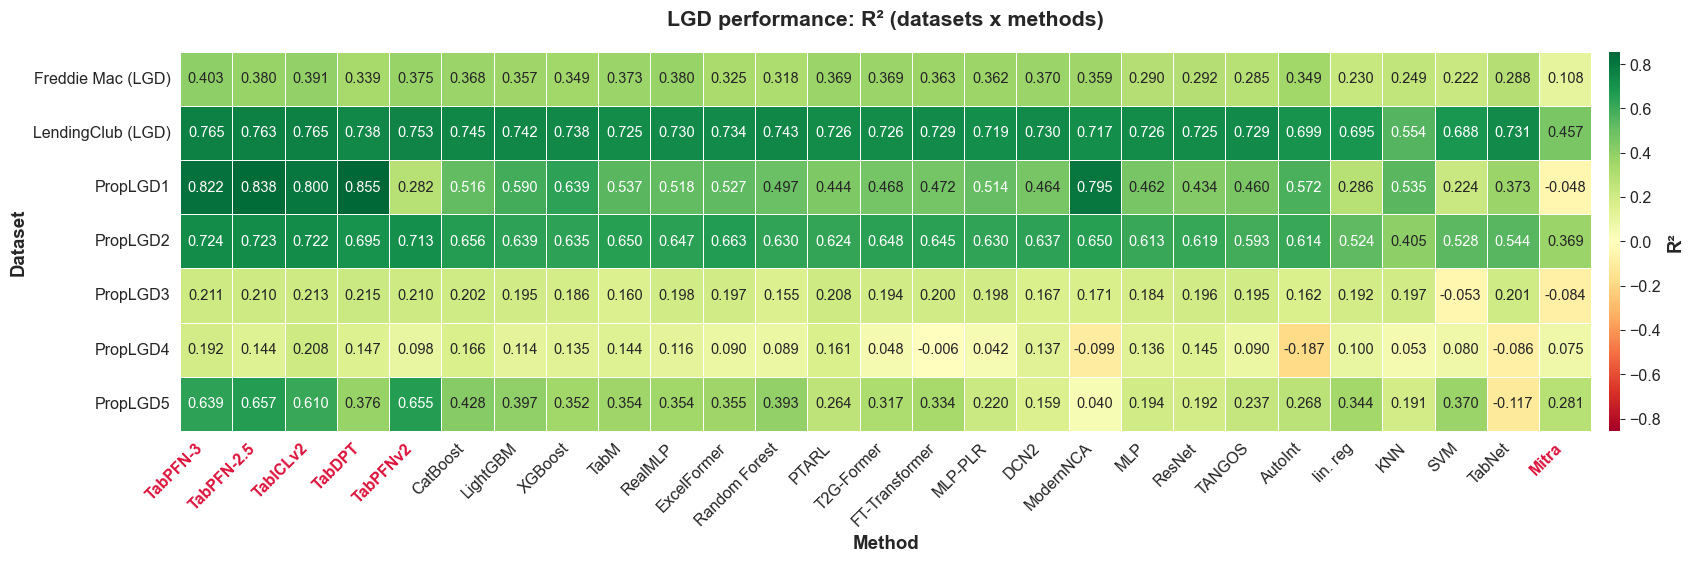

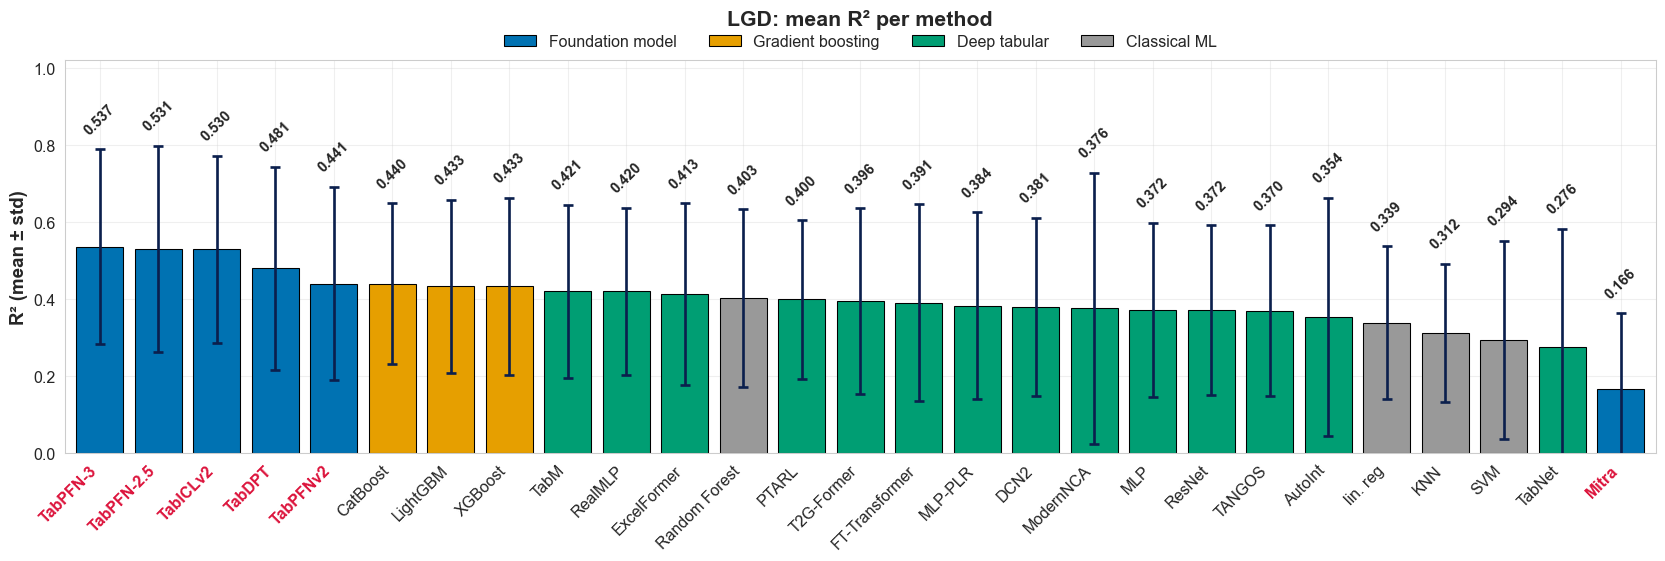

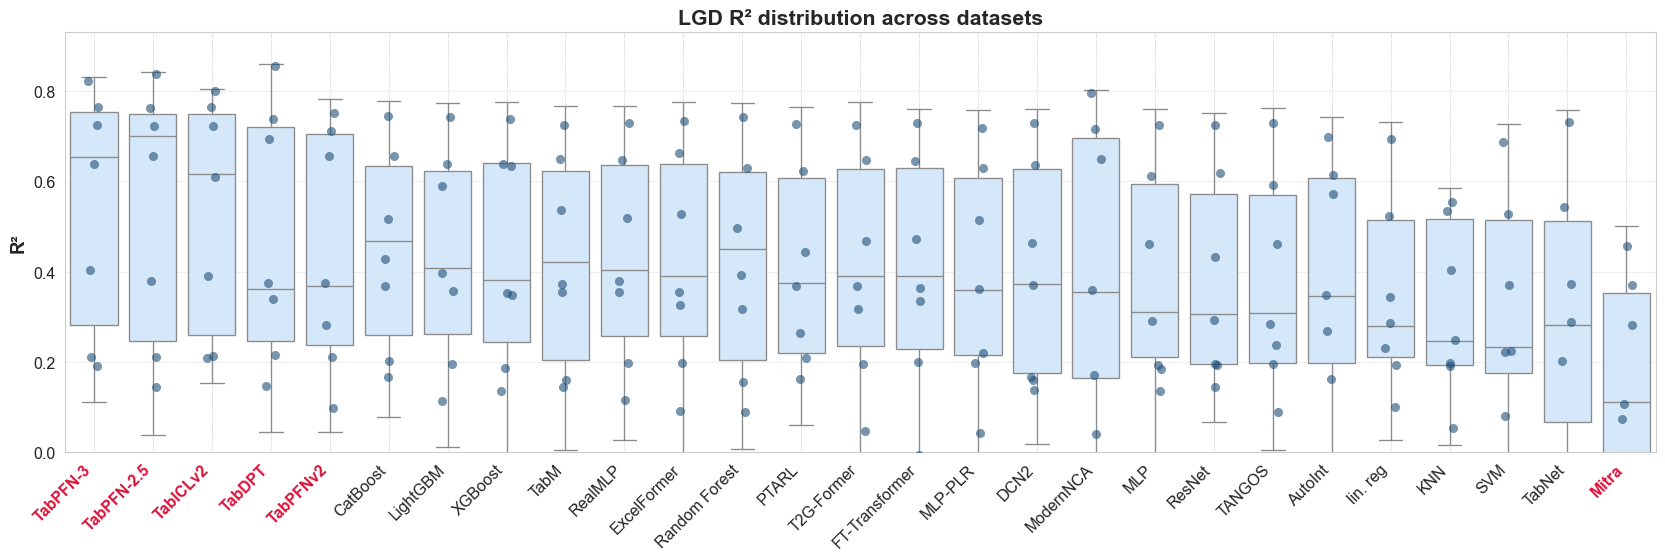

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_r2.pdf')

In [3]:
performance_heatmap(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)


## 2. Rank by R² (1 = best on that dataset)

The per-dataset ranking that underlies the R² table — kept right next to it. Matrix · mean-rank bar · rank box.

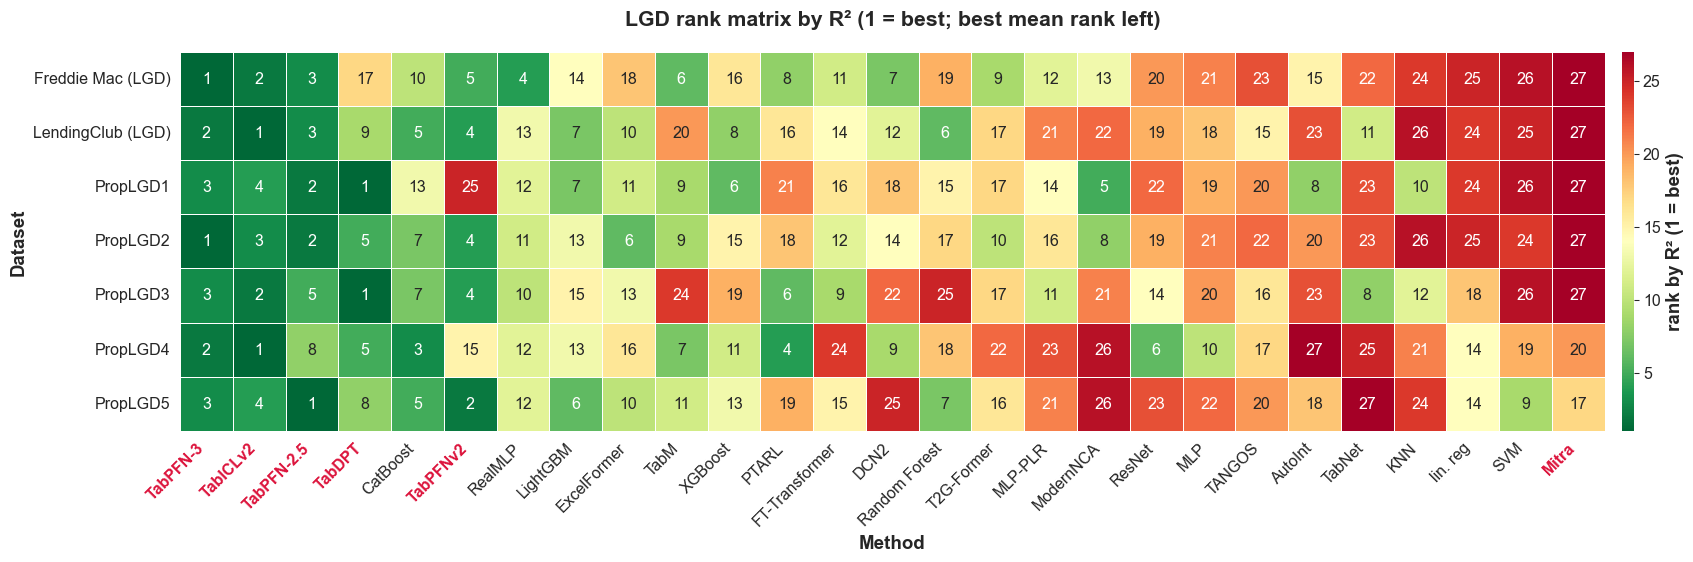

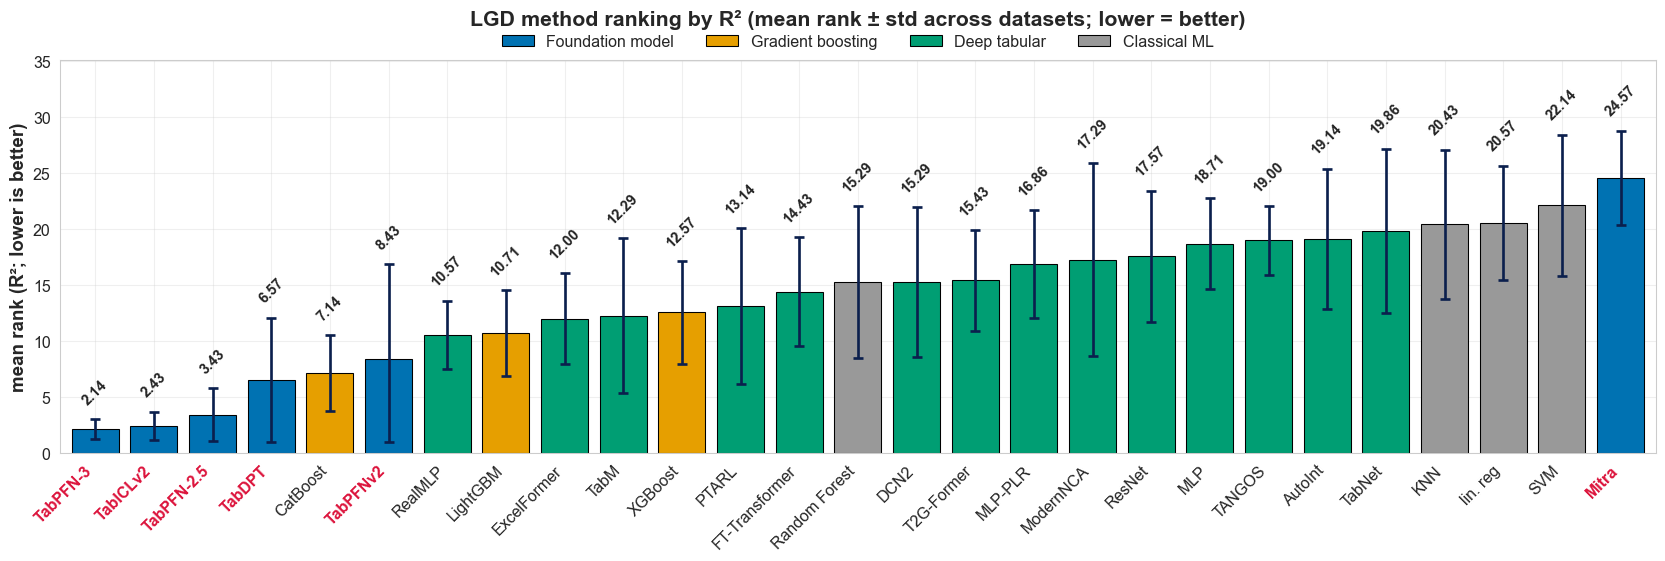

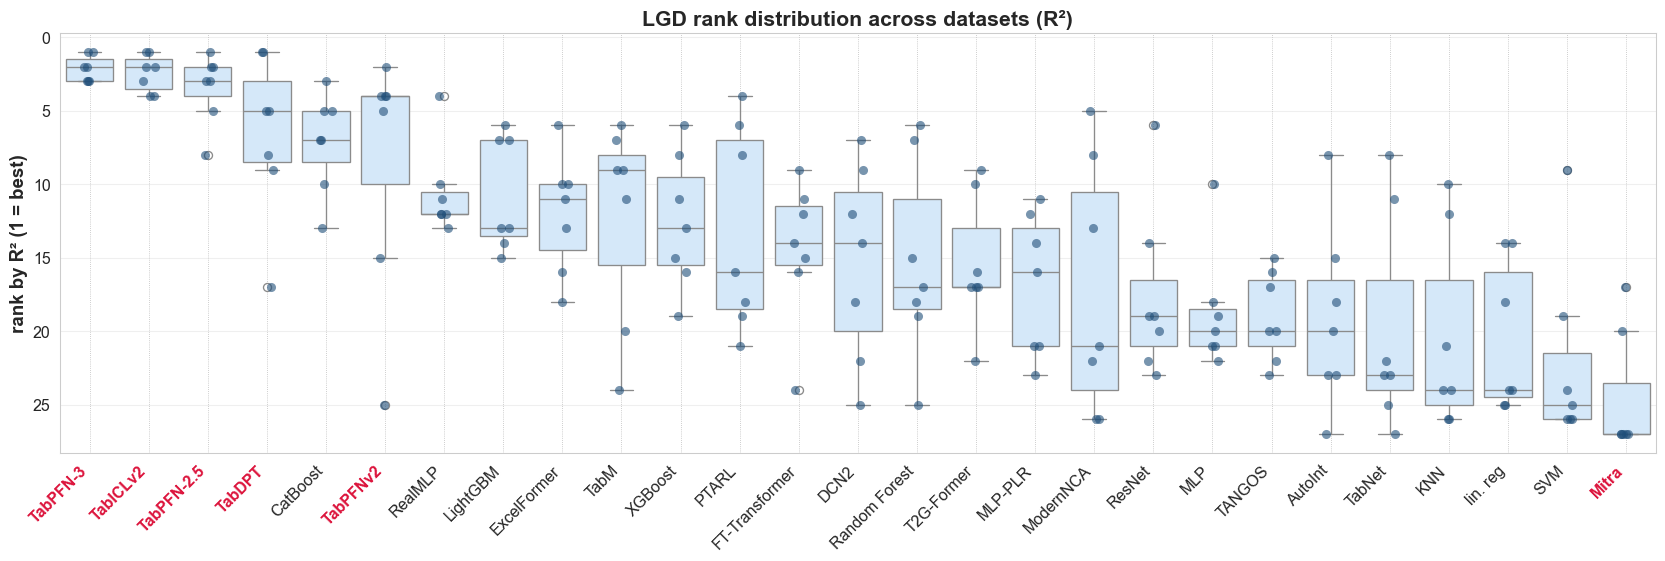

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_rank_box_r2.pdf')

In [4]:
rank_heatmap(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
method_ranking_bars(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)
rank_boxplots(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)


## 3. Pearson correlation

Linear association between predicted and realised LGD (higher is better). Matrix · bar · box.

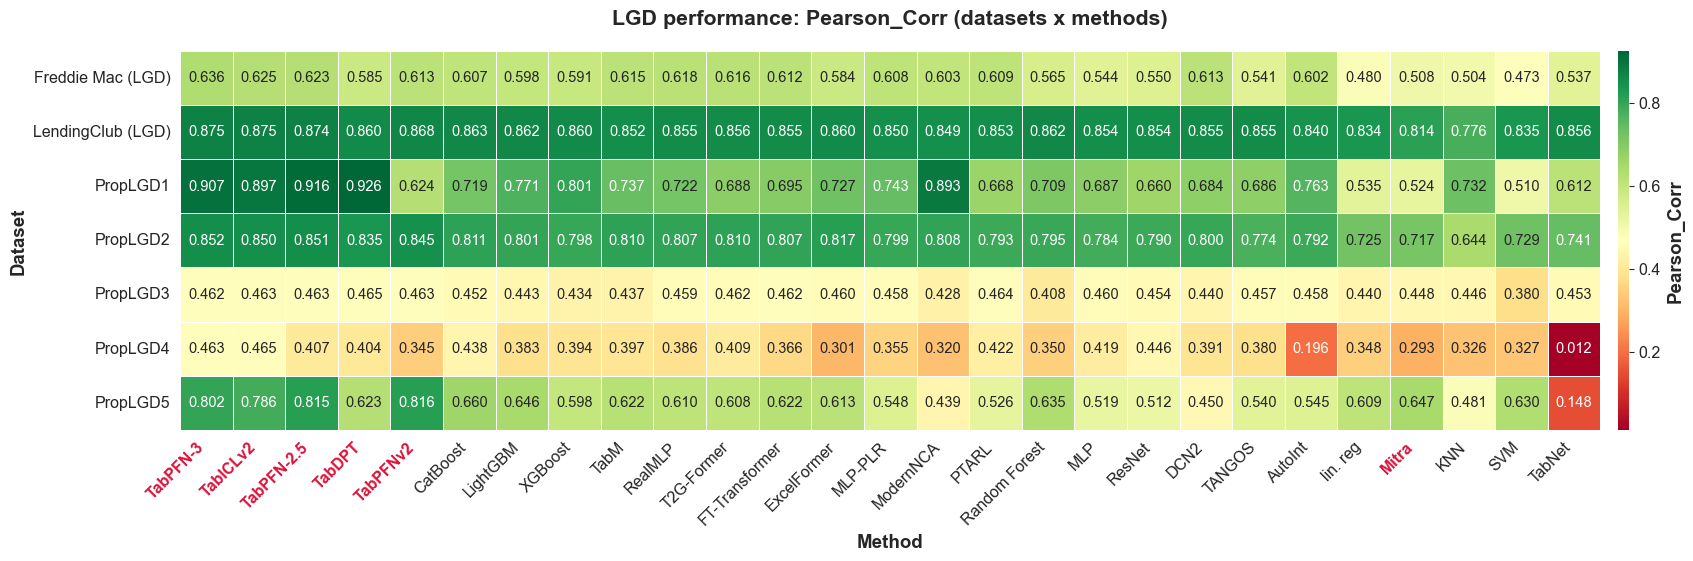

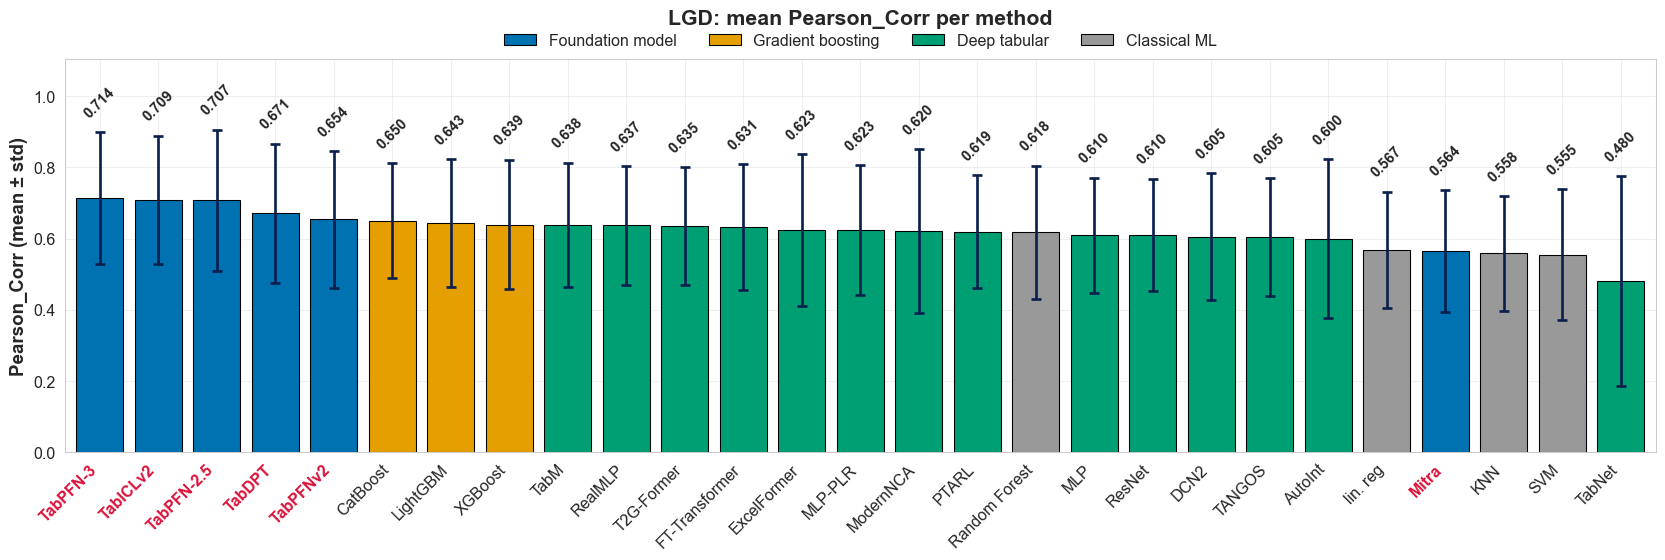

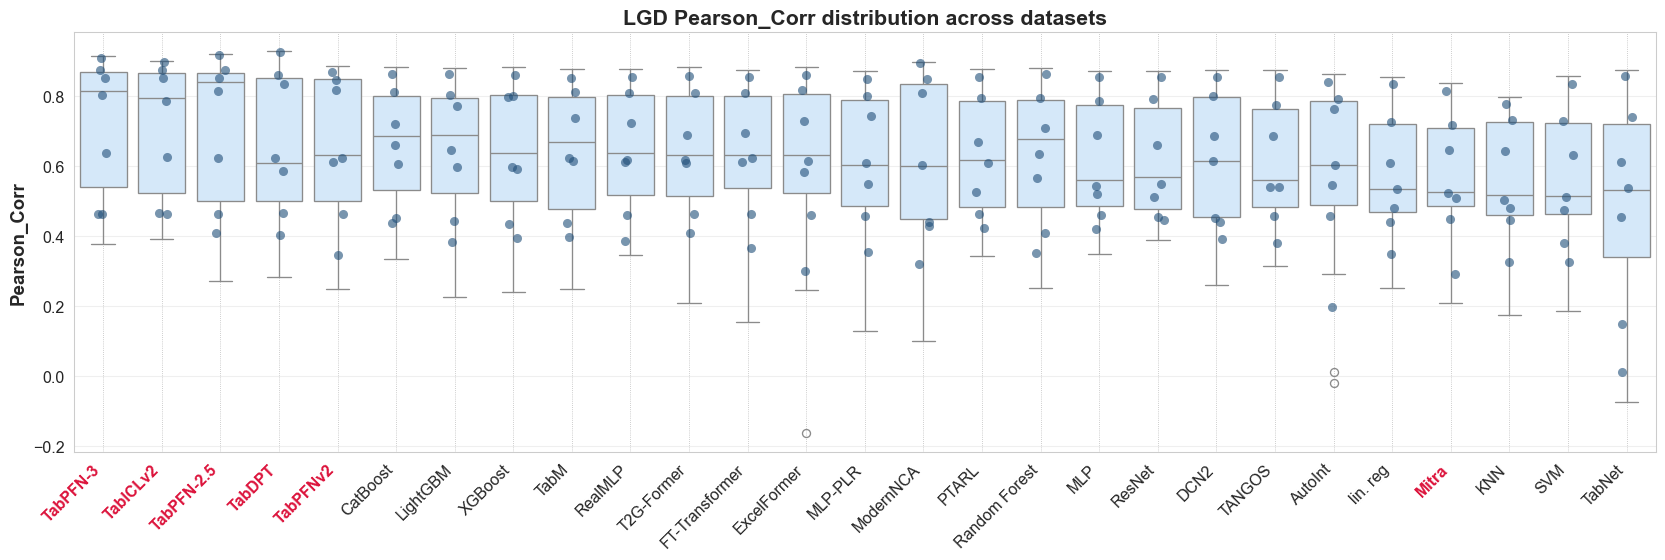

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_pearson_corr.pdf')

In [5]:
performance_heatmap(df, 'Pearson_Corr', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'Pearson_Corr', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'Pearson_Corr', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)


## 4. Effect of HPO on R²

Foundation models are 0 by design (their HPO run copies NO_HPO).

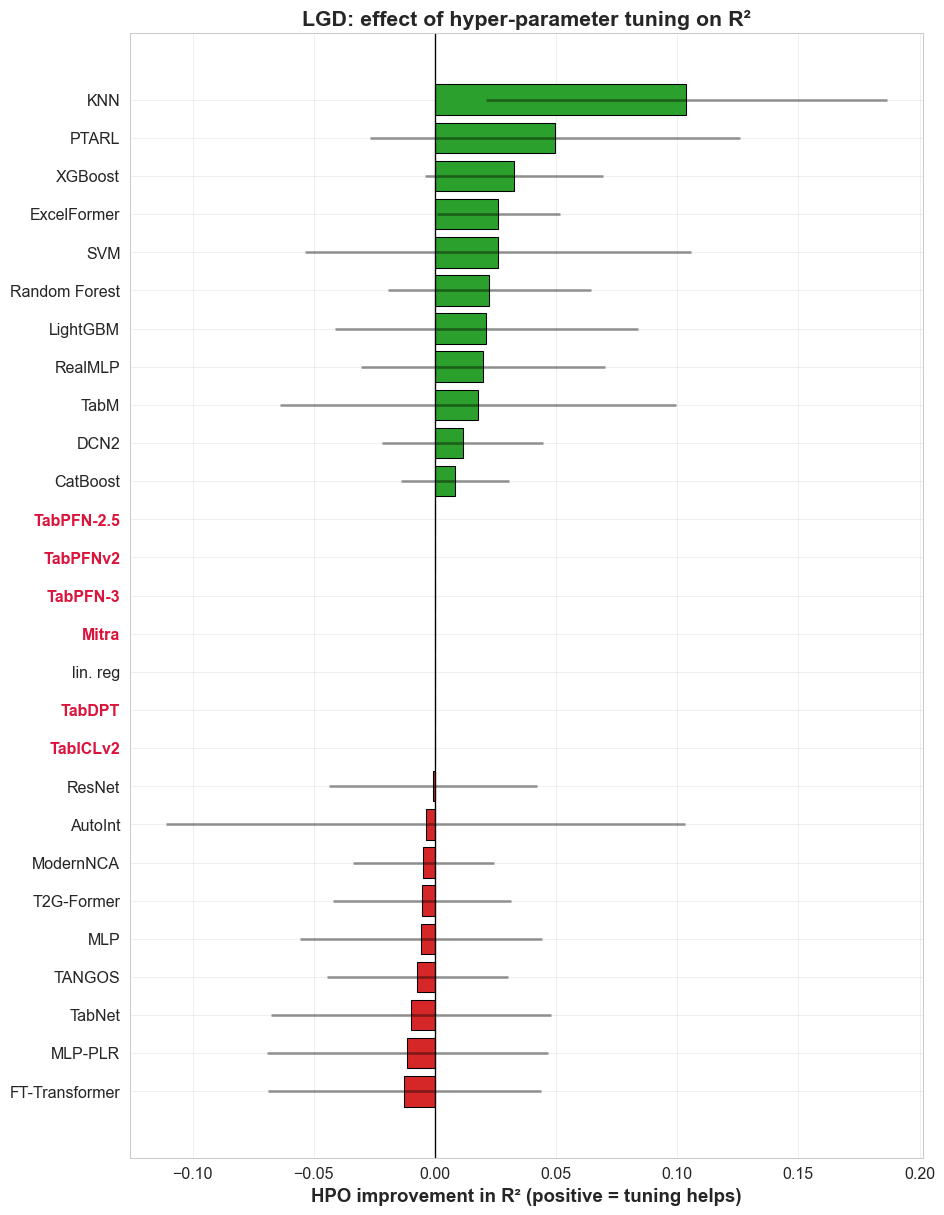

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_hpo_effect_r2.pdf')

In [6]:
hpo_improvement_bars(df_both, 'R2', task_name='LGD', out_dir=FIGURES_DIR)


## 5. Time analysis — train + predict + HPO

Tunable methods' training time × `n_trials` (the hyperparameter search) plus fit + predict; the boxplot shows the raw per-fold spread and the scatter the R²-vs-cost frontier (**median** time on x, **mean** R² on y).

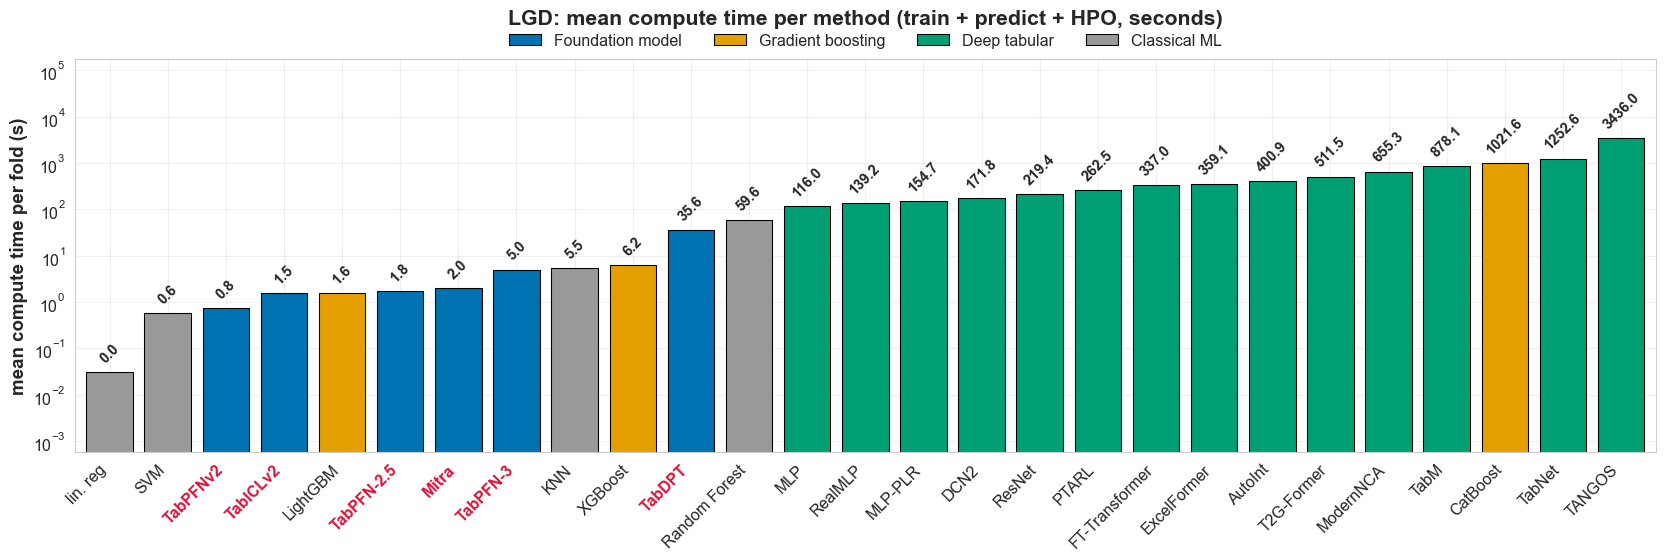

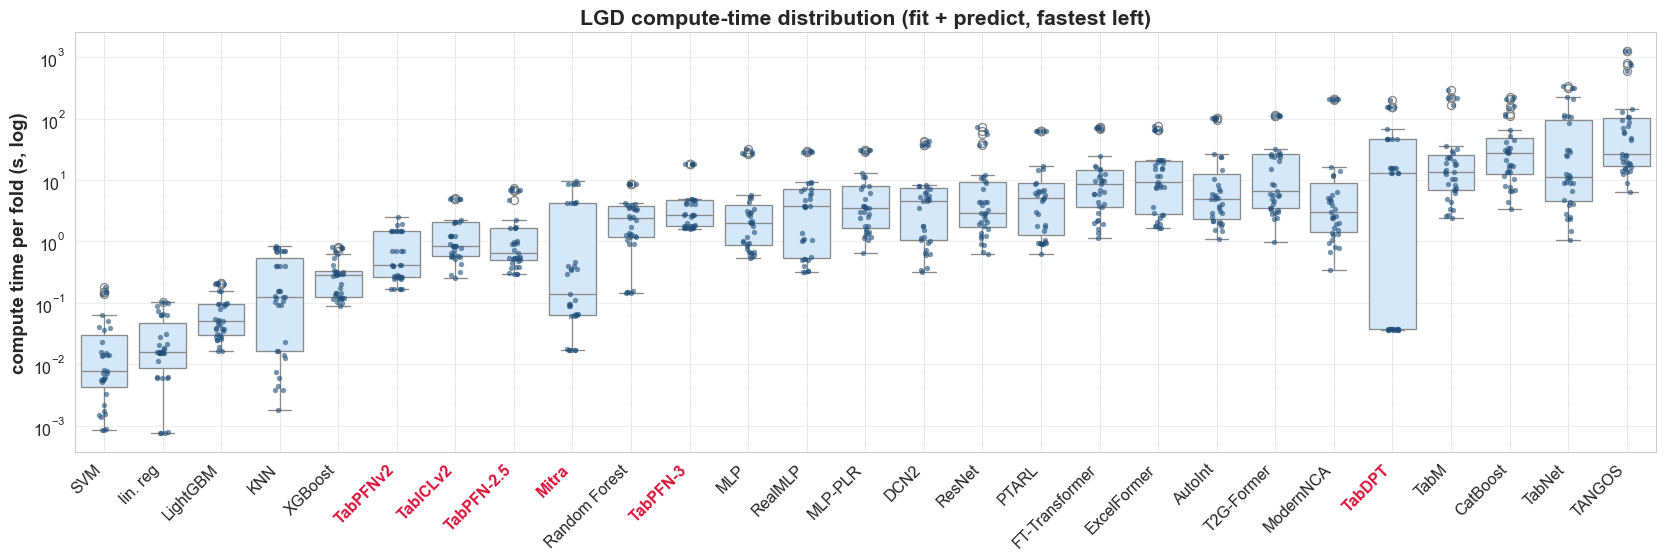

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_box_compute_time.pdf')

In [7]:
compute_time_bars(df, task_name='LGD', hpo_methods=HPO_METHODS, n_trials=20, out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='LGD', out_dir=FIGURES_DIR)


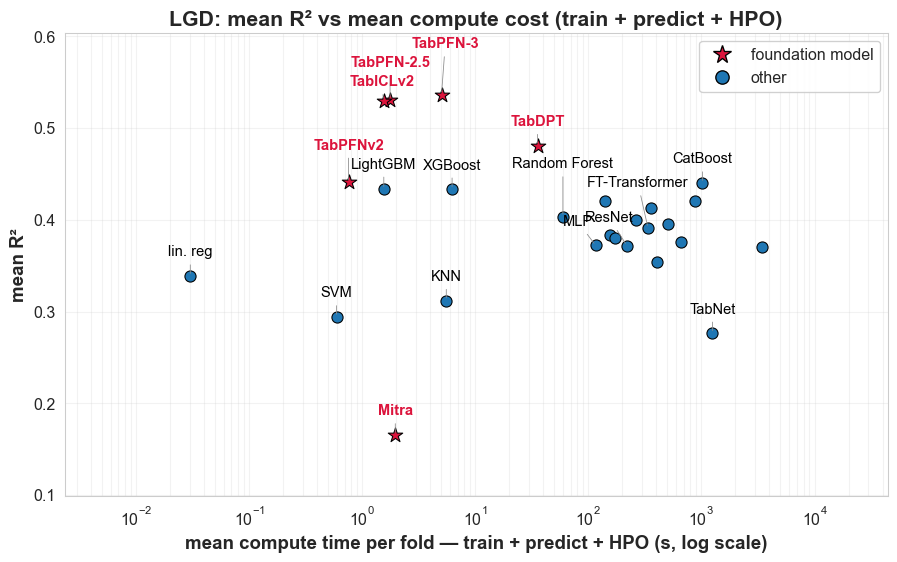

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_cost_quality_r2.pdf')

In [8]:
runtime_performance_scatter(df, 'R2', task_name='LGD', hpo_methods=HPO_METHODS, n_trials=20, out_dir=FIGURES_DIR)


## 6. TabPFN v3 vs the baselines — head-to-head

The foundation model against the two reference baselines in turn: **CatBoost** (strongest classical learner) and **lin. reg** (the regulatory / industry-standard credit baseline). For each, first the **relative R² improvement** per dataset against dataset size, with an OLS trend — does the edge grow on small data? Green = TabPFN v3 wins; the dashed line is equal performance. Then a per-dataset absolute R² scatter with the **y = x** equal-performance diagonal.

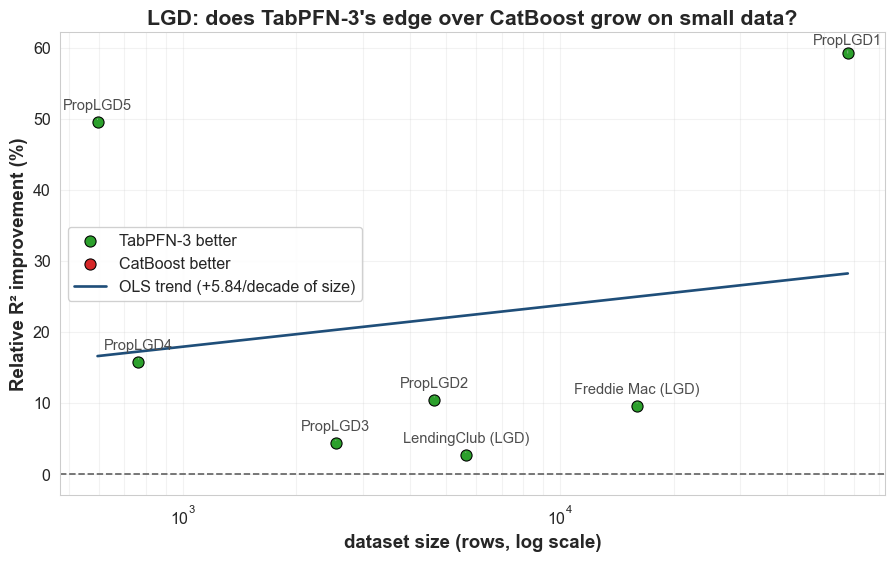

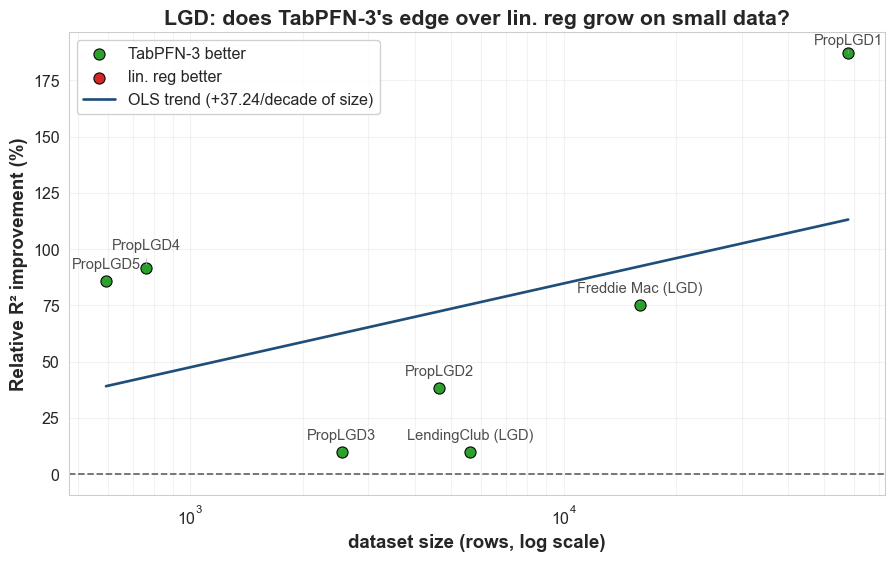

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_tabpfn_v3_vs_LinearRegression_sizetrend_r2.pdf')

In [9]:
foundation_vs_baseline_size_trend(df, metric='R2', task='lgd', task_name='LGD', relative=True, higher_is_better=True, out_dir=FIGURES_DIR)
foundation_vs_baseline_size_trend(df, metric='R2', task='lgd', task_name='LGD', base_method='LinearRegression', relative=True, higher_is_better=True, out_dir=FIGURES_DIR)


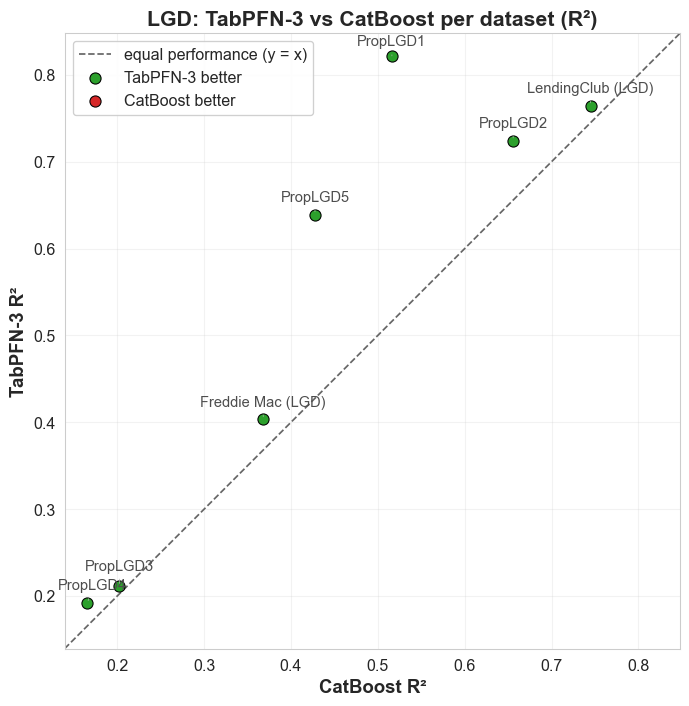

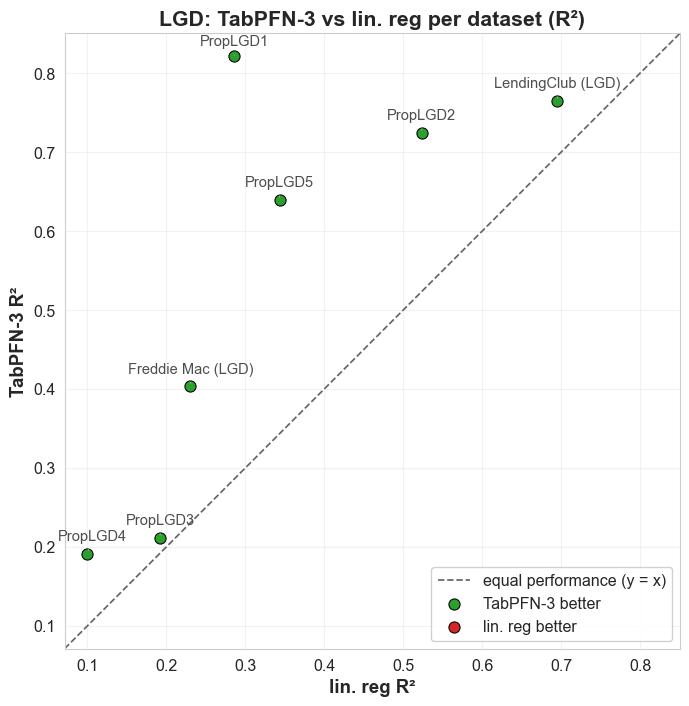

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_tabpfn_v3_vs_LinearRegression_scatter_r2.pdf')

In [10]:
foundation_vs_baseline_scatter(df, metric='R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
foundation_vs_baseline_scatter(df, metric='R2', base_method='LinearRegression', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)


## 7. Prediction calibration and systematic bias

Comparison restricted to TabPFN-3, TabICLv2, CatBoost, and lin. reg. Three views: the four-panel **observed-versus-predicted summary** (positive observed-minus-predicted values indicate underprediction), the **decile calibration curve** (loans ranked into predicted-LGD deciles per dataset; mean observed LGD per decile against the mean prediction, averaged over datasets), and the **bias-versus-mean-LGD scatter**, which shows whether miscalibration concentrates on the low- or high-LGD datasets.

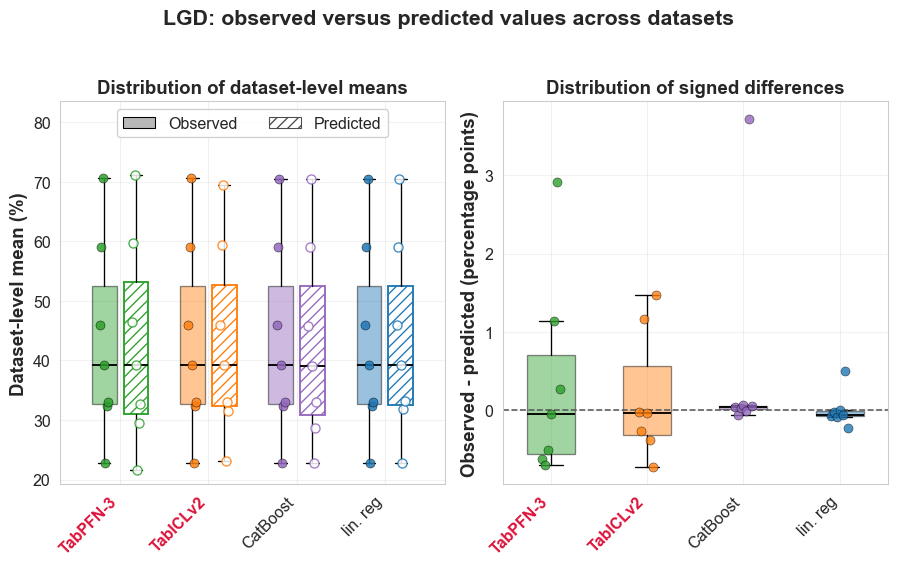

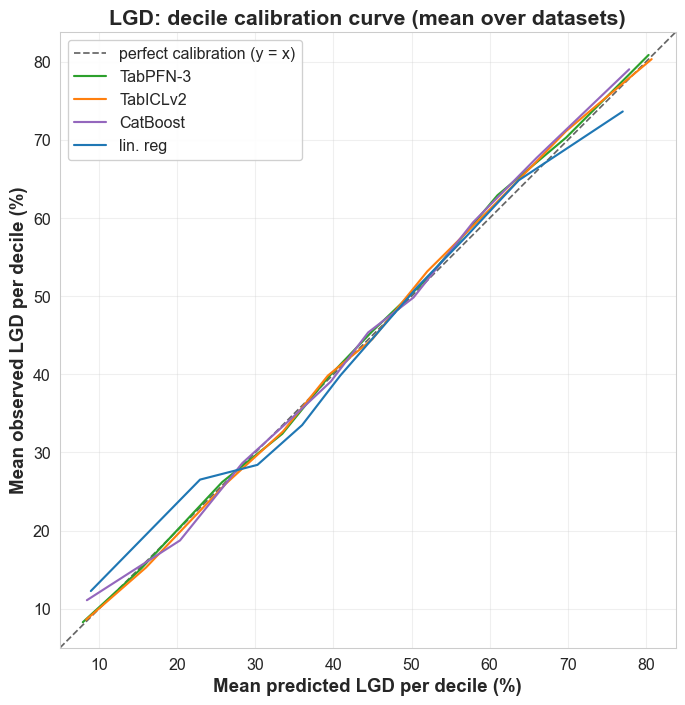

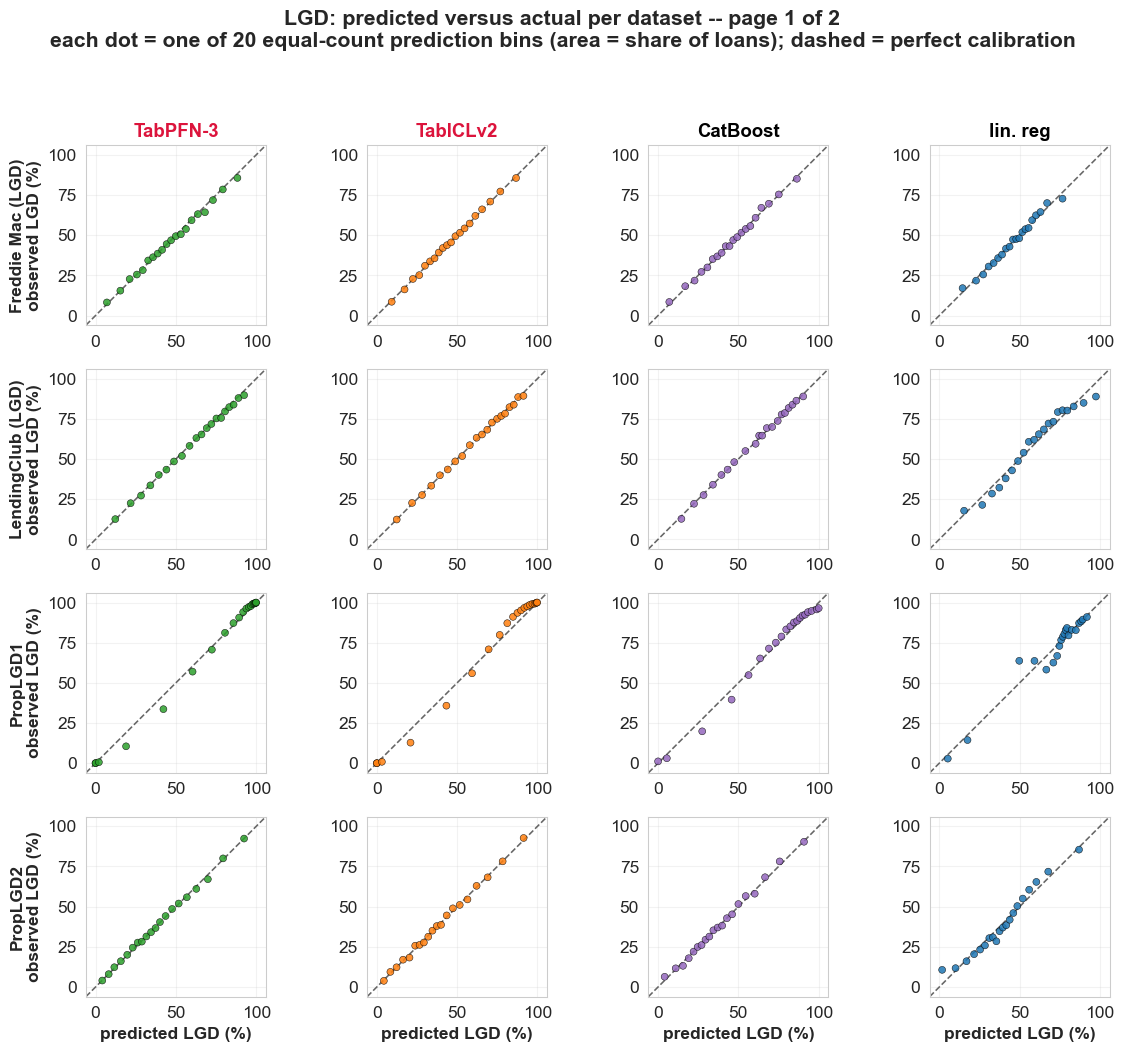

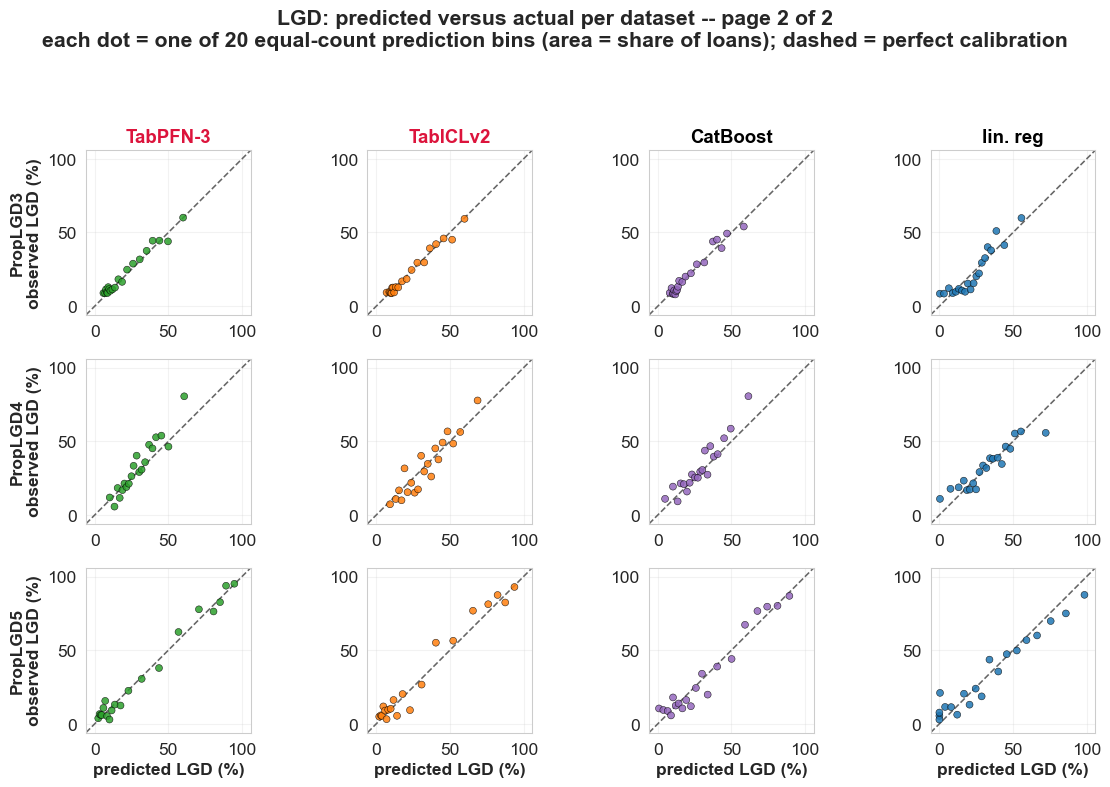

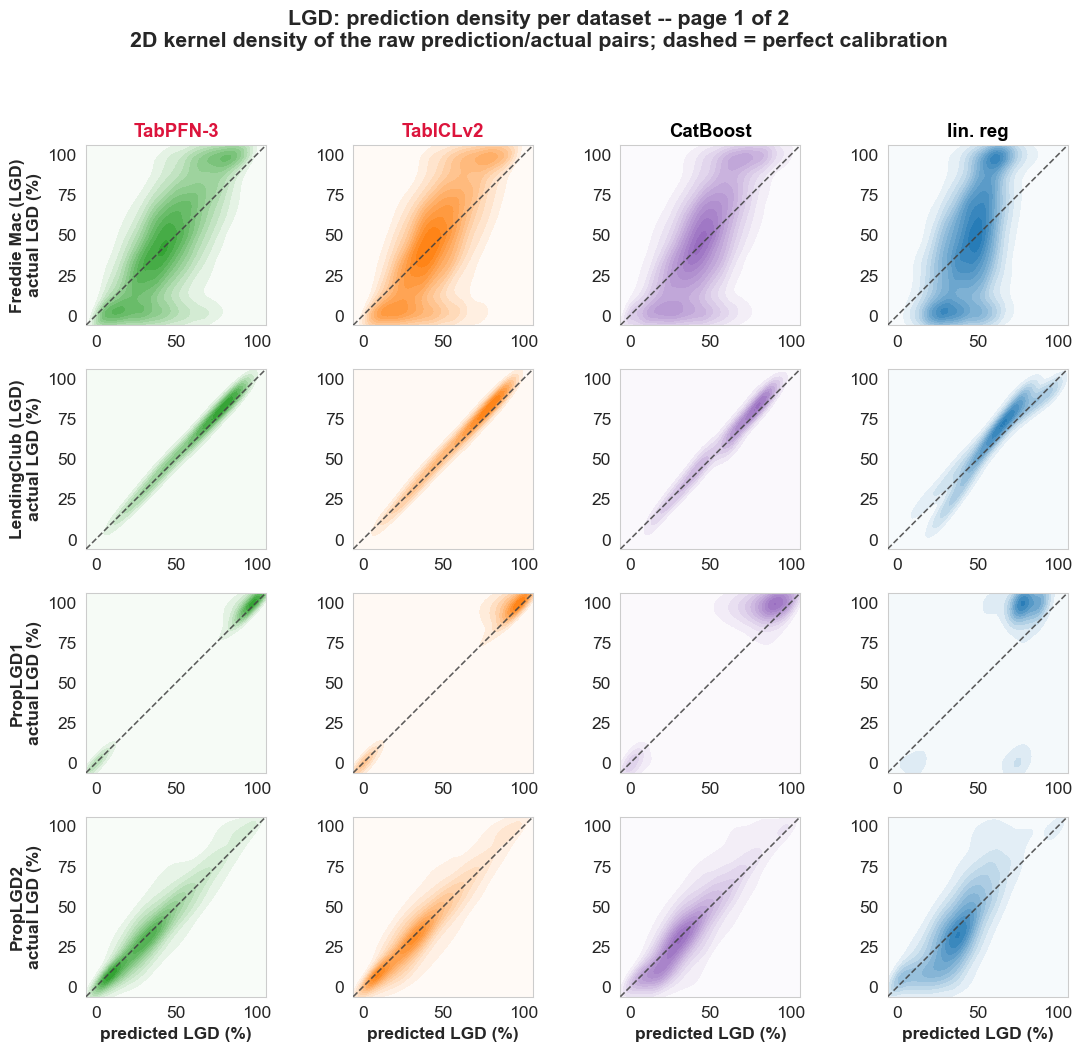

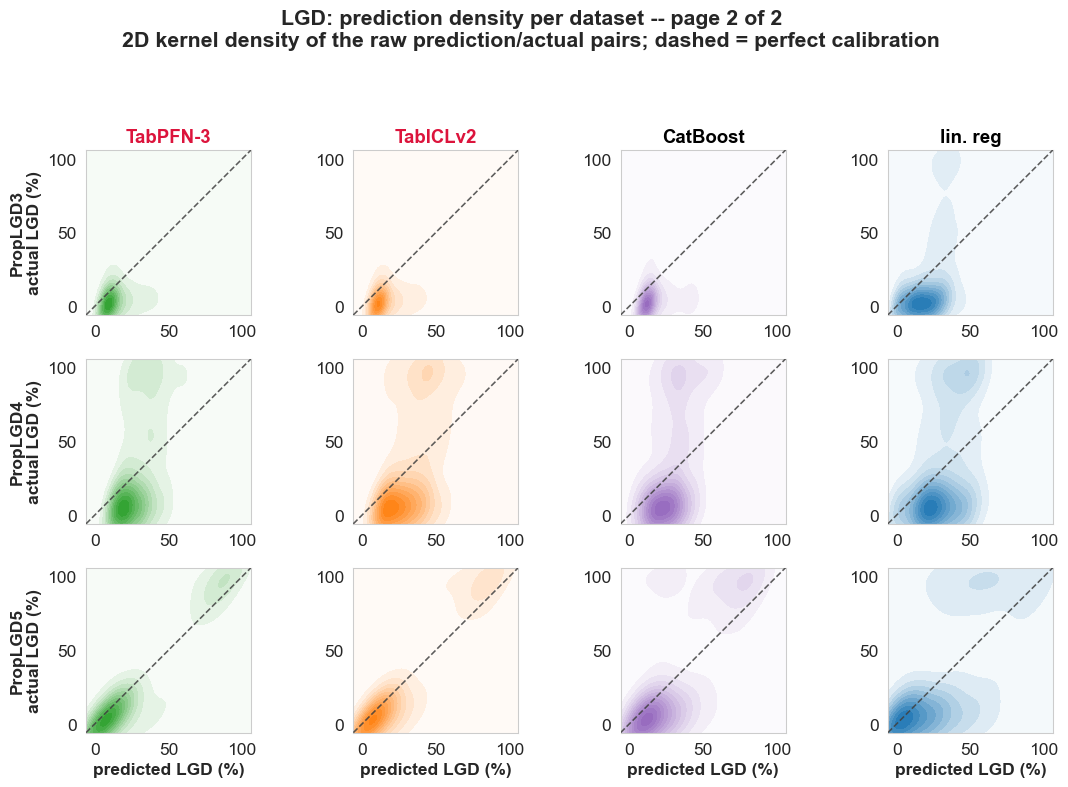

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_per_dataset_prediction_density_p1.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd/lgd_per_dataset_prediction_density_p2.pdf')]

In [11]:
lgd_calibration_methods = ('tabpfn_v3', 'tabicl_v2', 'catboost', 'LinearRegression')
lgd_calibration = calibration_bias_table(
    df, results_root=RESULTS_ROOT, task='lgd', methods=lgd_calibration_methods
)
selected_method_calibration_summary(
    lgd_calibration, task='lgd', methods=lgd_calibration_methods,
    task_name='LGD', out_dir=FIGURES_DIR
)
calibration_decile_curve(
    df, results_root=RESULTS_ROOT, task='lgd', methods=lgd_calibration_methods,
    task_name='LGD', out_dir=FIGURES_DIR
)
per_dataset_calibration_grid(
    df, results_root=RESULTS_ROOT, task='lgd', methods=lgd_calibration_methods,
    task_name='LGD', out_dir=FIGURES_DIR
)
per_dataset_prediction_density(
    df, results_root=RESULTS_ROOT, task='lgd', methods=lgd_calibration_methods,
    task_name='LGD', out_dir=FIGURES_DIR
)


## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [12]:
notebook_report(
    'Experiment 1 - LGD',
    notebook='Experiment1.4-LGD.ipynb',
    about=('5-fold CV headline LGD benchmark (tuned models): per-method metrics, '
           'ranks, tuning effect, compute time, TabPFN-3 vs the baselines, and the '
           'full prediction-calibration analysis.'),
    sections=[
        section('Coverage',
                f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets (HPO runs)'),
        section('Metrics per method (mean over datasets x folds) + compute time',
                capture(lgd_summary_text, df, task_name='Experiment 1 - LGD')),
        section('Average rank per method (R2)',
                capture(rank_summary_text, df, 'R2', task_name='LGD')),
        section('Effect of hyper-parameter tuning (R2)',
                capture(hpo_effect_text, df_both, 'R2', task_name='LGD')),
        section('TabPFN-3 head-to-head per dataset (R2)',
                capture(head_to_head_text, df, 'R2', fnd_method='tabpfn_v3',
                        base_methods=('catboost', 'LinearRegression'), task_name='LGD')),
        section('Prediction calibration (every calibration figure, in numbers)',
                capture(calibration_summary_text, lgd_calibration, task_name='LGD',
                        df=df, results_root=RESULTS_ROOT, task='lgd',
                        methods=lgd_calibration_methods)),
    ],
)

EXPERIMENT 1 - LGD -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment1.4-LGD.ipynb
Contents        : 5-fold CV headline LGD benchmark (tuned models): per-method metrics, ranks, tuning effect, compute time, TabPFN-3 vs the baselines, and the full prediction-calibration analysis.
Sections        : 6

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] Coverage
------------------------------------------------------------------------------
27 methods x 7 datasets (HPO runs)

------------------------------------------------------------------------------
[2] Metrics per method (mean over datasets x folds) + compute time
------------------------------------------------------------------------------
Experiment 1 - LGD — mean of every metric per method   (datasets: 7, m

"==============================================================================\nEXPERIMENT 1 - LGD -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment1.4-LGD.ipynb\nContents        : 5-fold CV headline LGD benchmark (tuned models): per-method metrics, ranks, tuning effect, compute time, TabPFN-3 vs the baselines, and the full prediction-calibration analysis.\nSections        : 6\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] Coverage\n------------------------------------------------------------------------------\n27 methods x 7 datasets (HPO runs)\n\n------------------------------------------------------------------------------\n[2] Metrics per method (mean over datase